# 1. EDA Figures: Price Landscape and Outcome Density

This notebook generates the two exploratory data-analysis figures that appear early in the paper:

- **Paper Figure 2:** sample bid, payment, and floor price distributions.
- **Paper Figure 3:** outcome density by day in the full configured Season 2 panel.

These figures are deliberately placed before replay, off-policy evaluation, and decision-support results. Their job is to establish that the empirical environment is both usable and nontrivial: prices have enough dispersion for reserve/floor policies to matter, and the constructed panel has enough day-level coverage to support the later policy analysis.

## How This Notebook Depends on Setup

Run `notebooks/0_setup.ipynb` before this notebook. The setup notebook creates the Season 2 and Season 3 panels, records archive metadata, and freezes the reserve/floor policy catalog. This notebook only consumes the setup artifacts; it does not rebuild raw panels.

Required inputs:

- `artifacts/workspace/data/processed/ipinyou_nuisance_prototype_opportunity_panel.parquet`
- `artifacts/workspace/metadata/season2_outcome_density.csv`

Generated outputs:

- `artifacts/figures/01_sample_price_distributions.png`
- `artifacts/figures/05_outcome_density_by_day.png`

In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root containing src/ and pyproject.toml")

REPO_ROOT = find_repo_root(Path.cwd().resolve())
SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Repository root: {REPO_ROOT}")

Repository root: /home/apex/Documents/ranking_sys/notebooks/writing/ads_marketplace_auction_experimentation/marketplace-policies-code


In [2]:
import pandas as pd
from IPython.display import Image, display

from checks import ArtifactRepository
from config import PaperConfig, ProjectPaths
from figures import FigureRenderer
from progress import ProgressLogger

## Artifact Access

The repository separates the **analysis workspace** from the **publication outputs**. The workspace contains data and metadata created by setup. The output folder contains regenerated paper figures and exported tables. Keeping these separate makes it easier to rerun downstream notebooks without accidentally overwriting the raw panel artifacts.

In [3]:
SOURCE_ROOT = REPO_ROOT / "artifacts" / "workspace"
OUTPUT_ROOT = REPO_ROOT / "artifacts"

paths = ProjectPaths.from_cli(SOURCE_ROOT, OUTPUT_ROOT)
paths.ensure_output_dirs()
repository = ArtifactRepository(paths)
repository.require_layout()

required_inputs = [
    paths.processed_data_dir / "ipinyou_nuisance_prototype_opportunity_panel.parquet",
    paths.metadata_dir / "season2_outcome_density.csv",
]
for path in required_inputs:
    if not path.exists():
        raise FileNotFoundError(f"Missing setup artifact: {path}")

print("Found required EDA inputs:")
for path in required_inputs:
    print(f"- {path.relative_to(REPO_ROOT)}")

Found required EDA inputs:
- artifacts/workspace/data/processed/ipinyou_nuisance_prototype_opportunity_panel.parquet
- artifacts/workspace/metadata/season2_outcome_density.csv


## Figure 2: Price Landscape

The first EDA question is whether reserve/floor experimentation is meaningful in this marketplace. If bids, pay prices, and logged floors were all tightly concentrated, then raising floors would either have almost no effect or would immediately destroy fill. A useful marketplace policy problem needs dispersion: some opportunities should have substantial bid-floor margin, while others should be fragile.

The figure below compares three price series:

- `bid_price`: the bid submitted for the opportunity.
- `slot_floor_price`: the logged floor attached to the slot.
- `pay_price`: the realized payment for filled impressions.

The plotted sample is truncated at the 99.5th percentile for each series so that the body of the distribution is readable. This is only a visualization choice; the replay calculations later use the configured panel data rather than the plotted truncated density.

In [4]:
price_panel = repository.read_parquet(
    "ipinyou_nuisance_prototype_opportunity_panel.parquet",
    columns=["bid_price", "pay_price", "slot_floor_price"],
)

price_summary = []
for column in ["bid_price", "slot_floor_price", "pay_price"]:
    values = price_panel[column].dropna()
    price_summary.append(
        {
            "series": column,
            "non_missing_rows": len(values),
            "mean": values.mean(),
            "p50": values.quantile(0.50),
            "p75": values.quantile(0.75),
            "p90": values.quantile(0.90),
            "p99": values.quantile(0.99),
            "p995": values.quantile(0.995),
            "max": values.max(),
        }
    )

pd.DataFrame(price_summary)

,series,non_missing_rows,mean,p50,p75,p90,p99,p995,max
0,bid_price,600000,272.895768,300.0,300.0,300.0,300.00,300.0,300.0
1,slot_floor_price,600000,47.301100,50.0,100.0,100.0,148.00,162.0,300.0
2,pay_price,137707,78.459352,70.0,92.0,166.0,261.94,276.0,300.0


The summary table is a numerical companion to Figure 2. The key thing to look for is not a single average; it is the spread across the median, upper quantiles, and extreme tail. That spread is what makes a selective floor policy plausible: a uniform policy can be too blunt, while a margin-aware policy can target opportunities with more apparent slack.

Wrote Figure 2 to artifacts/figures/01_sample_price_distributions.png


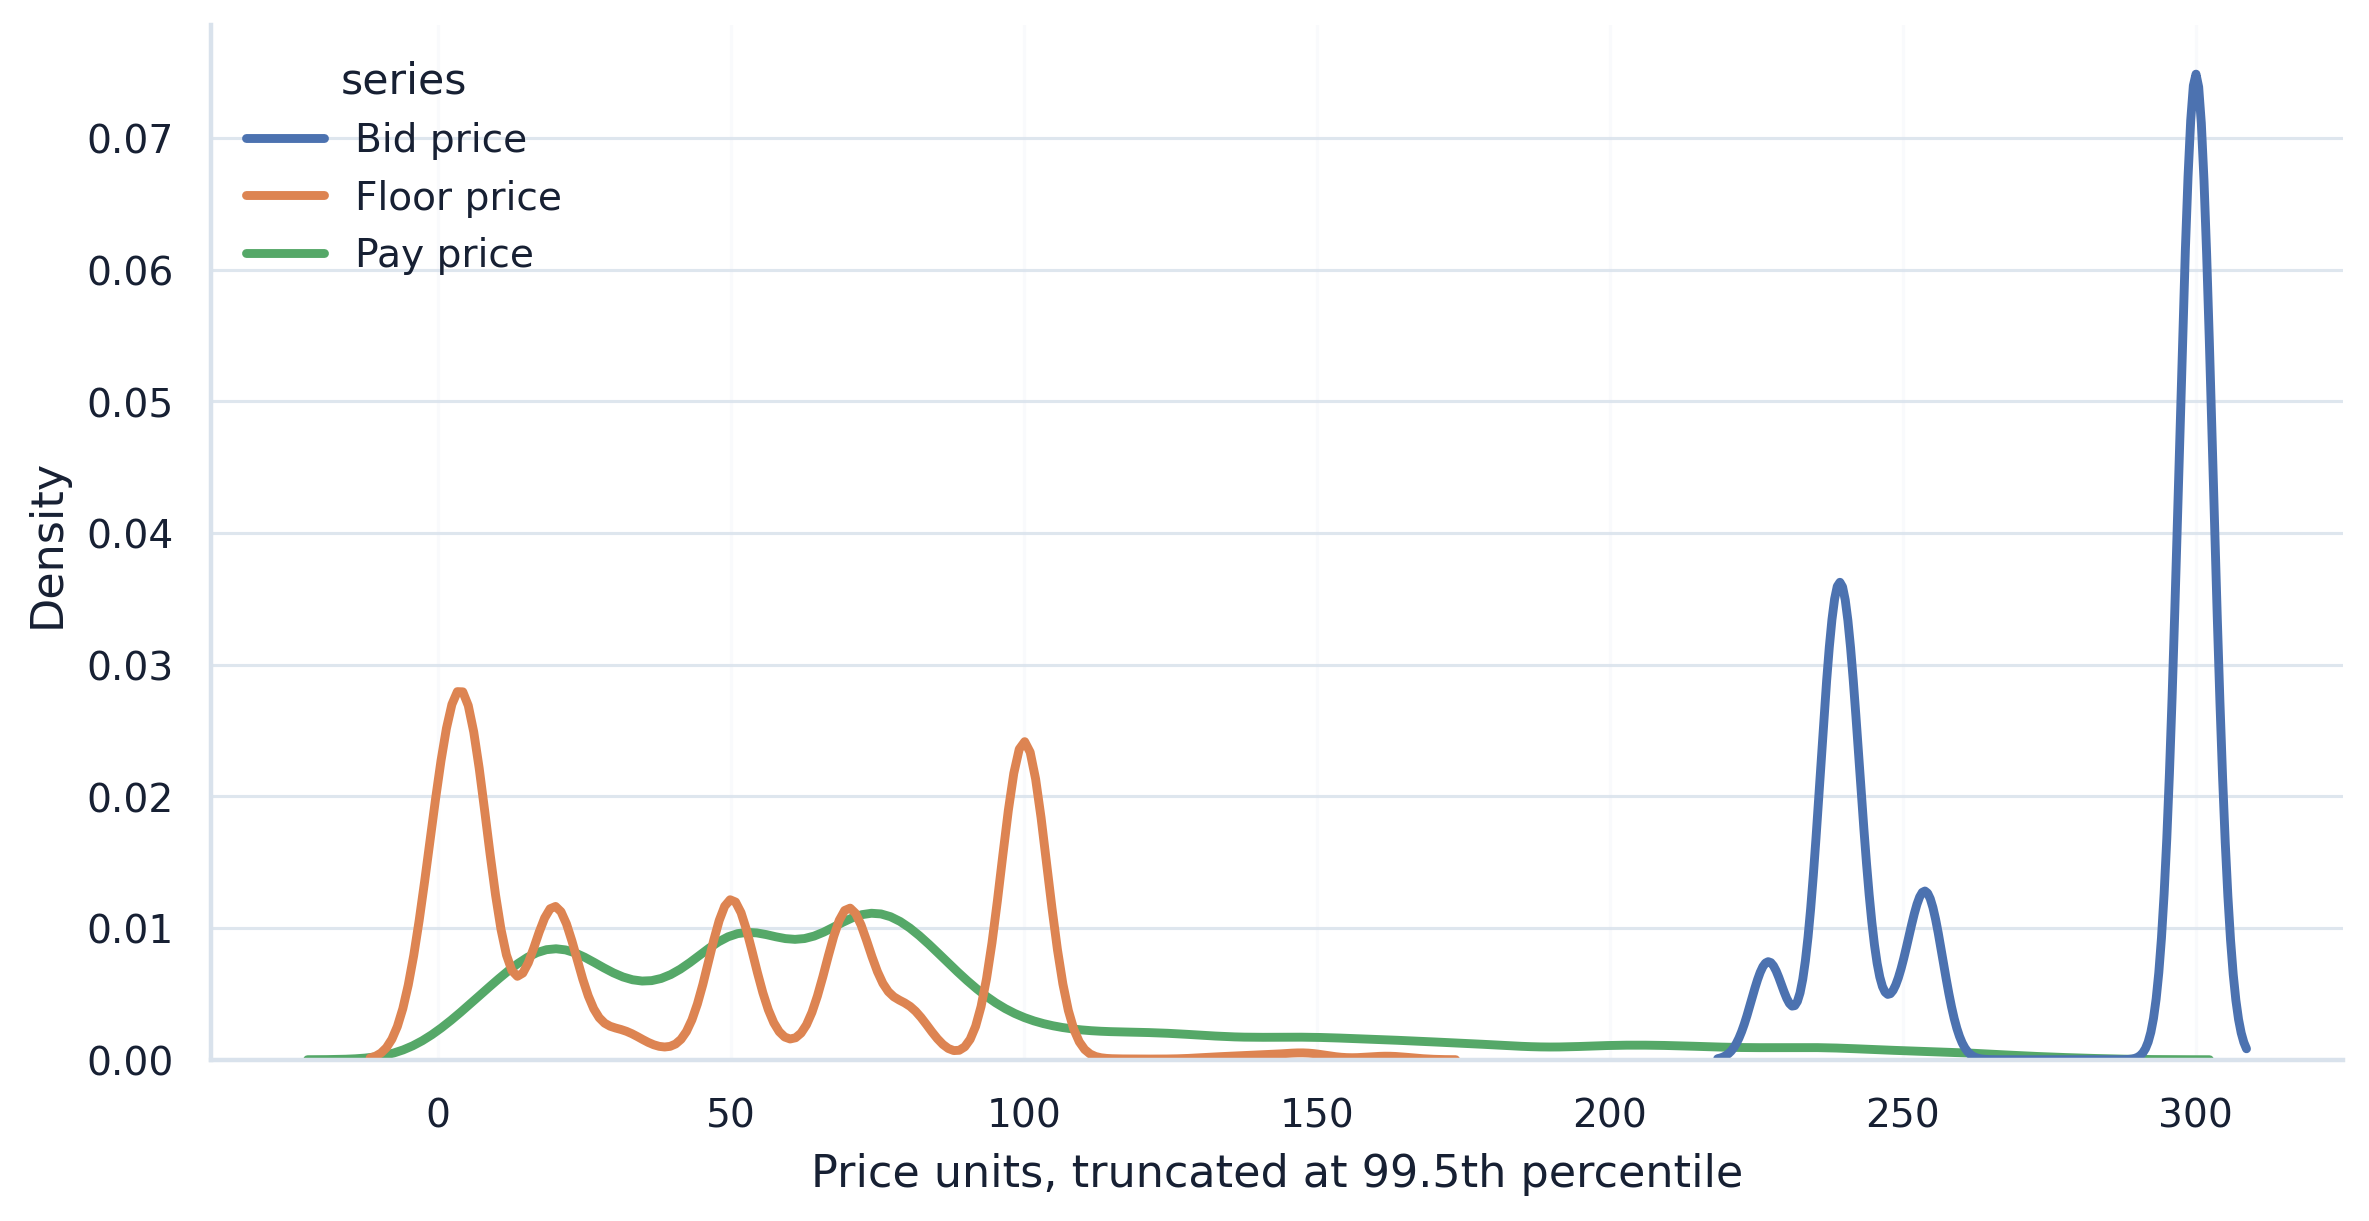

In [5]:
renderer = FigureRenderer(repository, paths.figure_dir, PaperConfig(), progress=ProgressLogger(enabled=True))
figure_2_path = renderer.plot_price_distributions()
print(f"Wrote Figure 2 to {figure_2_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(figure_2_path)))

### Interpretation for the Paper

Figure 2 supports the paper's first empirical claim: the auction environment contains meaningful price dispersion. In this setting, a reserve/floor intervention can plausibly increase yield on some rows, but it can also remove impressions on low-margin rows. This is exactly why the paper does not jump straight from replayed revenue gains to launch. The distributional evidence motivates later guardrails, support diagnostics, and external validation.

## Figure 3: Season 2 Outcome Density

The second EDA question is whether the constructed panel has enough day-level coverage for the main empirical analysis. Figure 3 is not a causal result. It is a panel-validity check: it shows the number of bid opportunities, the number of filled impressions, and the fill rate across the configured Season 2 dates.

This matters because reserve/floor replay is performed on the Season 2 panel shards. If one date had a very different scale or if the panel construction silently dropped most fills, then downstream policy comparisons could be dominated by construction artifacts rather than marketplace behavior.

In [6]:
density = repository.read_csv("season2_outcome_density.csv")
density["event_date"] = pd.to_datetime(density["event_date"])

density_summary = pd.DataFrame(
    [
        {
            "dates": density["event_date"].nunique(),
            "total_bid_opportunities": int(density["bid_opportunities"].sum()),
            "total_filled_impressions": int(density["filled"].sum()),
            "total_clicks": int(density["clicks"].sum()),
            "total_conversions": int(density["conversions"].sum()),
            "mean_daily_fill_rate": density["fill_rate"].mean(),
            "min_daily_fill_rate": density["fill_rate"].min(),
            "max_daily_fill_rate": density["fill_rate"].max(),
        }
    ]
)
density_summary

,dates,total_bid_opportunities,total_filled_impressions,total_clicks,total_conversions,mean_daily_fill_rate,min_daily_fill_rate,max_daily_fill_rate
0,7,53289330,12190344,8729,391,0.261444,0.138504,0.346804


In [7]:
density

,event_date,bid_opportunities,filled,clicks,conversions,fill_rate,click_rate_per_opportunity,conversion_rate_per_opportunity
0,2013-06-06,9586949,1815075,1149,38,0.189328,0.000120,0.000004
1,2013-06-07,11132555,1800104,1040,43,0.161697,0.000093,0.000004
2,2013-06-08,5226937,1629307,1154,35,0.311714,0.000221,0.000007
3,2013-06-09,11880893,1645556,1137,29,0.138504,0.000096,0.000002
4,2013-06-10,5610729,1911385,1511,108,0.340666,0.000269,0.000019
5,2013-06-11,5094845,1739373,1378,50,0.341399,0.000270,0.000010
6,2013-06-12,4756422,1649544,1360,88,0.346804,0.000286,0.000019


The daily table clarifies what Figure 3 compresses visually. `bid_opportunities` is the full opportunity count for each configured date, `filled` is the number of impressions observed in the logs, and `fill_rate` is the ratio of filled impressions to bid opportunities. Clicks and conversions are intentionally included here because later guardrails use click, conversion, and value-proxy retention, but the figure itself focuses on opportunity volume, fills, and fill rate.

Wrote Figure 3 to artifacts/figures/05_outcome_density_by_day.png


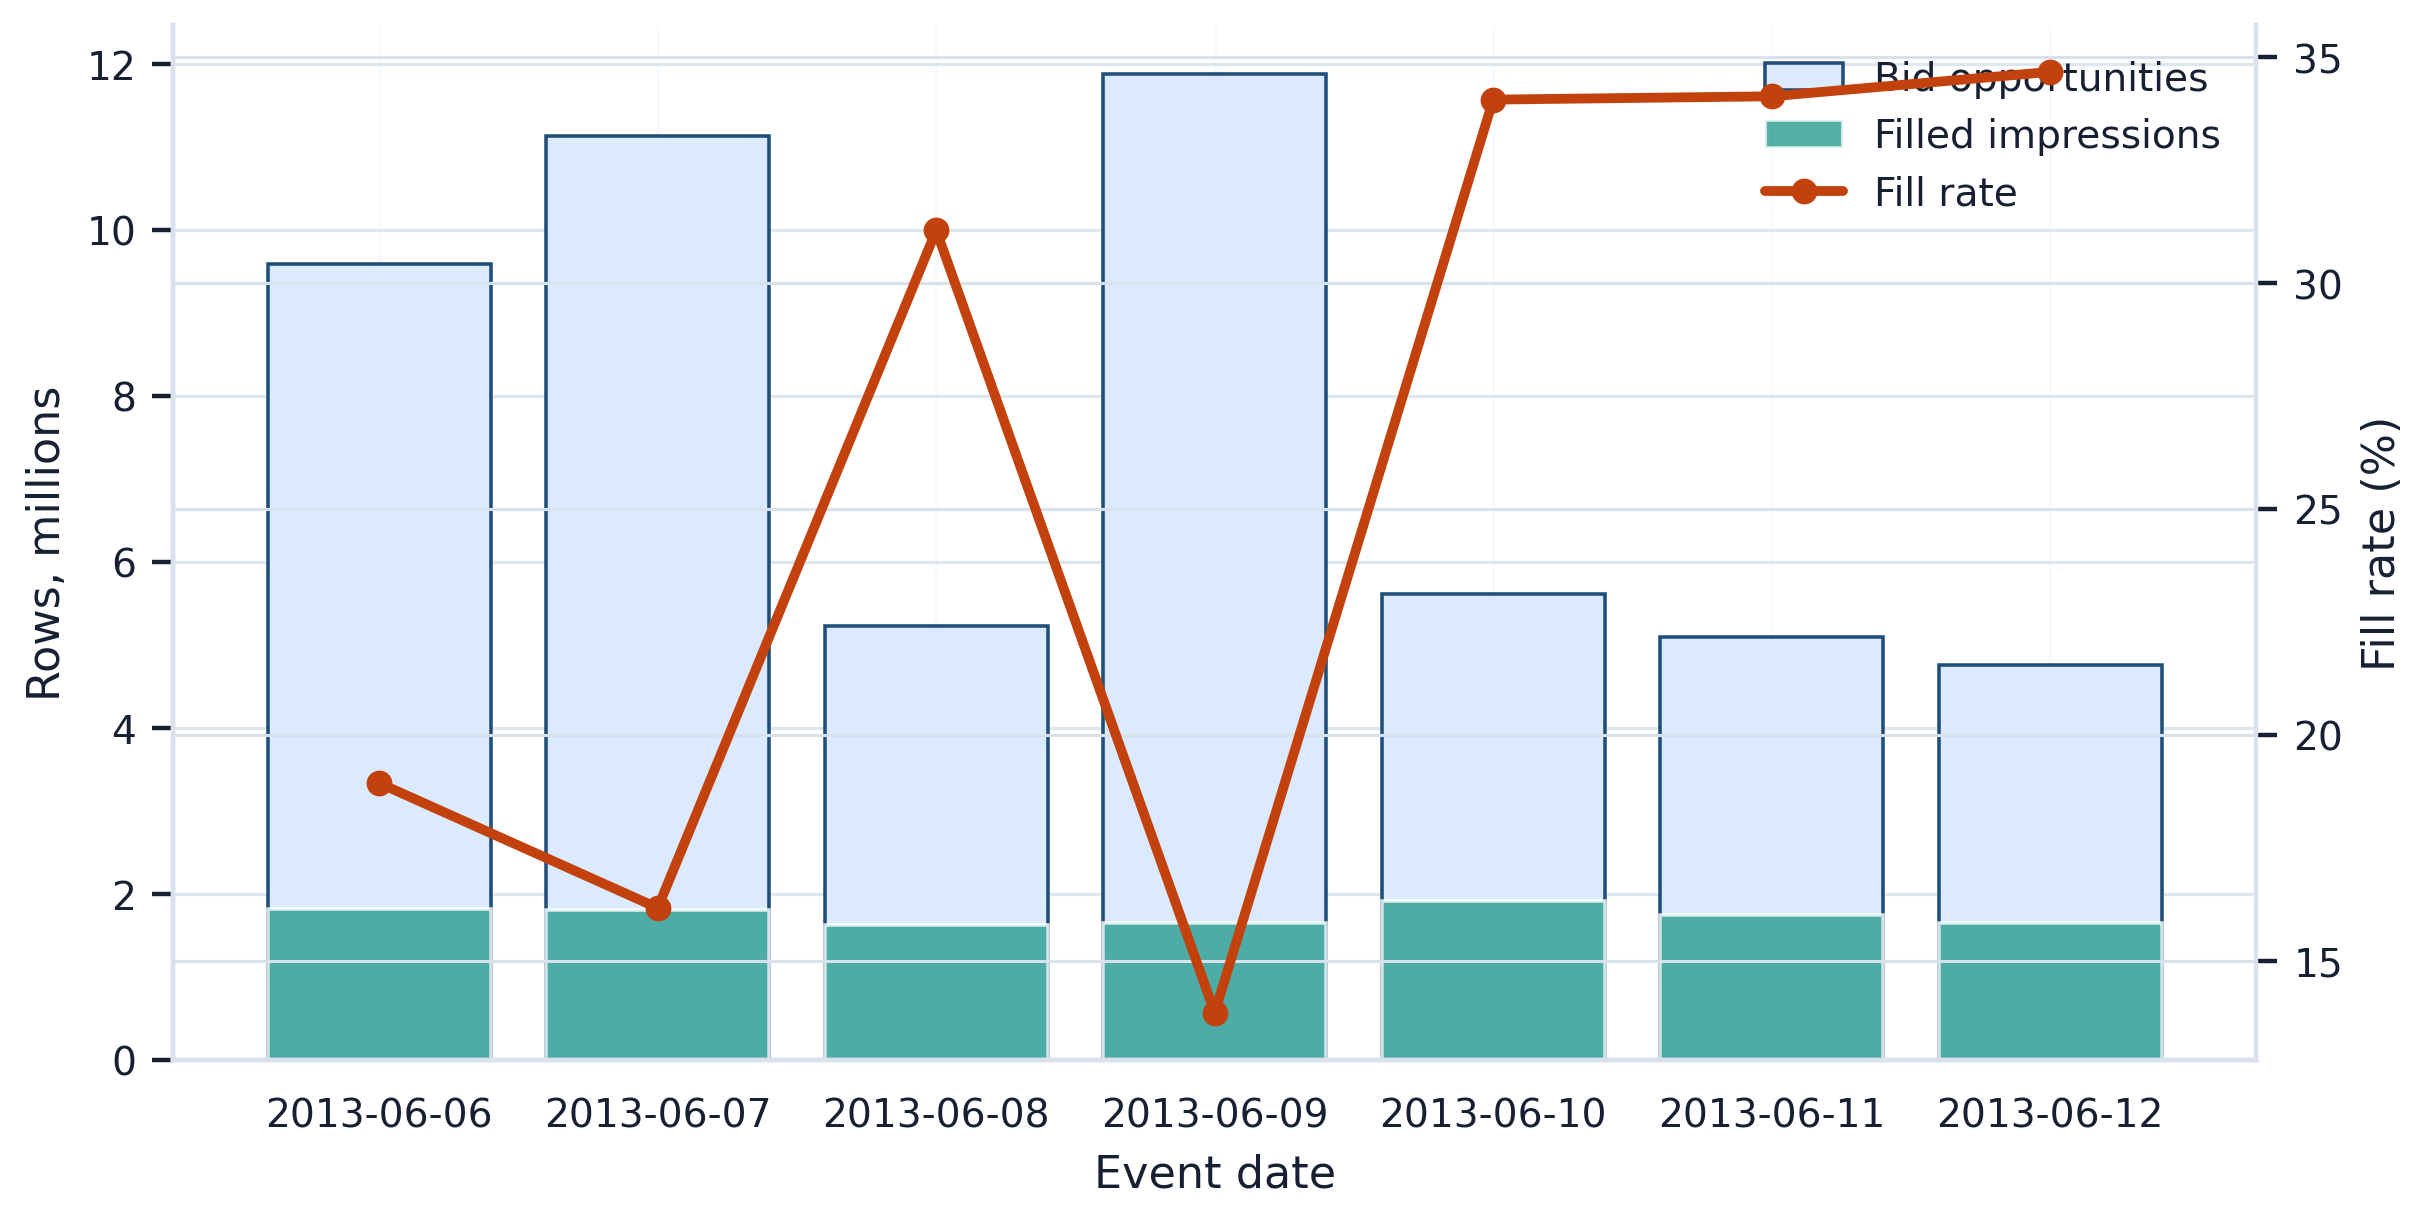

In [8]:
figure_3_path = renderer.plot_outcome_density()
print(f"Wrote Figure 3 to {figure_3_path.relative_to(REPO_ROOT)}")
display(Image(filename=str(figure_3_path)))

### Interpretation for the Paper

Figure 3 supports the paper's second empirical setup claim: the main analysis is built on a materialized Season 2 panel rather than on isolated audit samples. The figure gives readers a quick view of panel scale and daily fill behavior before the paper introduces reserve/floor replay. It also explains why later analysis reports both aggregate and daily guardrails: a policy can look good in aggregate while creating unacceptable delivery loss on a particular day.

## EDA Takeaways

Together, Figures 2 and 3 do three things for the paper. First, they show that the marketplace has enough price dispersion for reserve/floor policy to be an interesting decision problem. Second, they confirm that the empirical study is based on a constructed opportunity panel with observable daily scale and outcomes. Third, they set up the need for the next methodological layer: deterministic replay can quantify mechanical yield and fill changes, but the observed price dispersion and daily outcome variation mean that replay must be paired with guardrails, support checks, OPE diagnostics, and holdout validation before making a launch recommendation.